# Setup

In [72]:
# Imports
import numpy as np
from pathlib import Path
import pandas as pd
import torch
import random
from utils.utils import *
from data.simulate_walk_the_book import *
from utils.datastuff import TrainCfg
from utils.train import train_val
from utils.test import generate_test_loader, generate_test_predictions
from data.simulate_walk_the_book import simulate_walk_the_book
import warnings


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# Fix randomness for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

device: cpu


In [73]:
# are we consuming asks or bids?
side = "ask" # if positions are positive, we consume asks, if negative we consume bids.

In [74]:
import sys, os

# Paths and volume_to_fill
# root_path = DATA_PATH
root_path = "../data"
root = Path(root_path) if Path(root_path).exists() else Path.cwd()

import sys
if str(root / "src") not in sys.path:
    sys.path.append(str(root / "src"))

data_assets = [folder_name for folder_name in os.listdir(root) if "USDT" in folder_name]
data_asset = data_assets[0]

symbol_dir = root / data_asset
X_path = symbol_dir / "X_train.parquet"
Y_path = symbol_dir / "y_train.parquet"
X_test_path = symbol_dir / "X_test.parquet"
vol_path = symbol_dir / "vol_to_fill.txt"

volume_to_fill = None
if vol_path.exists():
    import re
    with open(vol_path) as f:
        m = re.search(r"([\d.]+)", f.read())
    if m:
        volume_to_fill = float(m.group(1))
print("data asset:", data_asset)
print("volume_to_fill:", volume_to_fill)

data asset: BTCUSDT
volume_to_fill: 4.0


In [75]:
volumes_to_fill = {}

for asset in data_assets:
    vol_path = root / asset / "vol_to_fill.txt"
    if vol_path.exists():
        with open(vol_path) as f:
            m = re.search(r"([\d.]+)", f.read())
        if m:            
            volumes_to_fill[asset] = float(m.group(1)) 

import matplotlib.pyplot as plt

def plot_volumes_to_fill():
    # Sort dictionary by values
    sorted_items = sorted(volumes_to_fill.items(), key=lambda x: x[1])

    # Unzip keys and values
    labels, values = zip(*sorted_items)

    # Create bar plot
    plt.figure()
    plt.bar(labels, values)

    # Optional labels
    plt.xlabel("Items")
    plt.ylabel("Values")
    plt.title("Volumes to Fill by Asset")

    plt.show()

In [76]:
# DeepLOB only take LOB features as input
LOB_COLS = []
for i in range(1, 6):
    LOB_COLS.append(f"ask_price_{i}")
    LOB_COLS.append(f"ask_vol_{i}")
    LOB_COLS.append(f"bid_price_{i}")
    LOB_COLS.append(f"bid_vol_{i}")

FEATURE_COLS = LOB_COLS + ["target"]

In [77]:
ASK_PRICE_COLS = ['ask_price_1', 'ask_price_2', 'ask_price_3', 'ask_price_4', 'ask_price_5']
ASK_VOL_COLS = ['ask_vol_1', 'ask_vol_2', 'ask_vol_3', 'ask_vol_4', 'ask_vol_5']
BID_PRICE_COLS = ['bid_price_1', 'bid_price_2', 'bid_price_3', 'bid_price_4', 'bid_price_5']
BID_VOL_COLS = ['bid_vol_1', 'bid_vol_2', 'bid_vol_3', 'bid_vol_4', 'bid_vol_5']

In [78]:
df_k = pd.DataFrame({
    "Asset": [
        "BTCUSDT", "ETHUSDT", "LTCUSDT",
        "SOLUSDT", "ADAUSDT", "DOGEUSDT", "XRPUSDT"
    ],
    "Optimal_K": [
        14, 26, 16,
        17, 7, 20, 20
    ],
    "bps_optimal_K": [
        1.323212, 2.712073, 4.819771,
        5.343504, 4.628115, 4.976437, 3.567023
    ]
})

In [79]:

optimal_k = df_k[df_k["Asset"] == data_asset]["Optimal_K"].iloc[0]

In [80]:
X_df = pd.read_parquet(X_path)
y_df = pd.read_parquet(Y_path)

ids = pd.Series(X_df["anonymized_id"].unique(), name="anonymized_id")

last_time = X_df["time_in_hour"].iloc[-1]
future_times = pd.Series(
    [last_time + pd.Timedelta(seconds=i) for i in range(1, 61)],
    name="time_in_hour"
)

full_grid = (
    ids.to_frame()
    .merge(future_times.to_frame(), how="cross")
)

y_df = full_grid.merge(
    y_df,
    on=["anonymized_id", "time_in_hour"],
    how="left"
)

# NOTE: we don't want to impute because Maaz also used missingness as a feature
# price imputation
# price_cols = ASK_PRICE_COLS + BID_PRICE_COLS + ["close"]
# X_df[price_cols] = X_df.groupby("anonymized_id")[price_cols].transform(lambda x: x.ffill().bfill())
# y_df[price_cols] = y_df.groupby("anonymized_id")[price_cols].transform(lambda x: x.ffill().bfill())

# # volume imputation
# volume_cols = BID_VOL_COLS + ASK_VOL_COLS + ["volume"]
# X_df[volume_cols] = X_df[volume_cols].fillna(0)
# y_df[volume_cols] = y_df[volume_cols].fillna(0)

In [81]:
y_df = pd.read_parquet(Y_path)

ids = pd.Series(X_df["anonymized_id"].unique(), name="anonymized_id")

last_time = X_df["time_in_hour"].sort_values().iloc[-1]
future_times = pd.Series(
    [last_time + pd.Timedelta(seconds=i) for i in range(1, 61)],
    name="time_in_hour"
)

full_grid = (
    ids.to_frame()
    .merge(future_times.to_frame(), how="cross")
)

y_df = full_grid.merge(
    y_df,
    on=["anonymized_id", "time_in_hour"],
    how="left"
)

# Model K

| Feature Name                  | Description                                                                 |
|------------------------------|-----------------------------------------------------------------------------|
| w300_rel_spread_mean         | Average relative spread over the last 5 visible minutes; indicates recent market tightness |
| w900_rel_spread_std          | Spread variability over the last 15 visible minutes; indicates stability of market tightness |
|||
| w900_close_missing_rate      | Fraction of missing close values over the last 15 visible minutes; proxy for activity / coverage / sparsity |
| w300_close_missing_rate      | Missing close rate over the last 5 visible minutes; short-term coverage / sparsity proxy |
|||
| w300_abs_return_sum          | Cumulative absolute return over the last 5 visible minutes; measures price noisiness/jumpiness |
|||
| w1800_trade_volume_mean      | Average trade volume over the last 30 visible minutes; medium-term activity level |
| w60_trade_volume_mean        | Average trade volume over the last visible minute; reflects very recent trading activity |
| w3540_trade_volume_mean      | Average trade volume across the full visible 59 minutes; overall hourly activity level |

In [82]:
# so we want to create a model that predicts optimal k for each anonymized id. It's probably best to have a model for each asset.

## Create X

In [83]:
X_df.columns

Index(['ask_price_1', 'ask_vol_1', 'bid_price_1', 'bid_vol_1', 'ask_price_2',
       'ask_vol_2', 'bid_price_2', 'bid_vol_2', 'ask_price_3', 'ask_vol_3',
       'bid_price_3', 'bid_vol_3', 'ask_price_4', 'ask_vol_4', 'bid_price_4',
       'bid_vol_4', 'ask_price_5', 'ask_vol_5', 'bid_price_5', 'bid_vol_5',
       'open', 'high', 'low', 'close', 'volume', 'anonymized_id',
       'time_in_hour'],
      dtype='str')

In [84]:
# Make X train data

X_df = X_df.sort_values(["anonymized_id", "time_in_hour"])

X_df["ask_price_1"] = X_df["ask_price_1"].ffill().bfill()
X_df["bid_price_1"] = X_df["bid_price_1"].ffill().bfill()

mid = (X_df["ask_price_1"] + X_df["bid_price_1"]) / 2
X_df["rel_spread"] = (X_df["ask_price_1"] - X_df["bid_price_1"]) / mid

X_df["w300_rel_spread_mean"] = (
    X_df.groupby("anonymized_id")["rel_spread"]
    .transform(lambda x: x.rolling(window=60*5).mean())
)

X_df["w900_rel_spread_std"] = (
    X_df.groupby("anonymized_id")["rel_spread"]
    .transform(lambda x: x.rolling(window=60*15).std())
)

X_df["w900_close_missing_rate"] = X_df.groupby("anonymized_id")["close"].transform(lambda x: x.isna().rolling(window=60*15).mean())
X_df["w300_close_missing_rate"] = X_df.groupby("anonymized_id")["close"].transform(lambda x: x.isna().rolling(window=60*5).mean())

X_df["logmid"] = np.log(mid)
X_df["return"] = X_df.groupby("anonymized_id")["logmid"].diff().abs()
X_df["w300_abs_return_sum"] = X_df.groupby("anonymized_id")["return"].transform(lambda x: x.rolling(window=60*5).sum())

X_df["volume"] = X_df["volume"].fillna(0)
X_df["w1800_trade_volume_mean"] = X_df.groupby("anonymized_id")["volume"].transform(lambda x: x.rolling(window=60*30).mean())
X_df["w60_trade_volume_mean"] = X_df.groupby("anonymized_id")["volume"].transform(lambda x: x.rolling(window=60).mean())
X_df["w3540_trade_volume_mean"] = X_df.groupby("anonymized_id")["volume"].transform(lambda x: x.mean())

last_time = X_df["time_in_hour"].max()

X_df_model = X_df[X_df["time_in_hour"] == last_time][[
    'anonymized_id', 
                   
    'w300_rel_spread_mean', 
    'w900_rel_spread_std', 
    
    'w900_close_missing_rate', 
    'w300_close_missing_rate',
    
    'w300_abs_return_sum',

    'w1800_trade_volume_mean',
    'w60_trade_volume_mean',
    'w3540_trade_volume_mean'
    ]].reset_index(drop=True)

X_df_model

,anonymized_id,w300_rel_spread_mean,w900_rel_spread_std,w900_close_missing_rate,w300_close_missing_rate,w300_abs_return_sum,w1800_trade_volume_mean,w60_trade_volume_mean,w3540_trade_volume_mean
0,10076153343292355,0.000133,0.000080,0.280000,0.320000,0.009788,0.039557,0.020101,0.059815
1,11952371325098172,0.000110,0.000089,0.115556,0.180000,0.012969,0.234819,0.291922,0.276742
2,55046619254322768,0.000058,0.000068,0.318889,0.346667,0.010879,0.158416,0.100824,0.142999
3,80222719501999508,0.000219,0.000113,0.355556,0.393333,0.013618,0.092256,0.031241,0.090256
4,123316967431224104,0.000131,0.000102,0.445556,0.353333,0.010689,0.024898,0.105161,0.023974
...,...,...,...,...,...,...,...,...,...
700,18275309064788010886,0.000027,0.000041,0.078889,0.086667,0.013467,0.304075,0.215744,0.239129
701,18300485165035687626,0.000156,0.000102,0.434444,0.426667,0.010847,0.074748,0.084891,0.135650
702,18343579412964912222,0.000143,0.000086,0.345556,0.386667,0.010670,0.054902,0.046333,0.049794
703,18388549878875942635,0.000077,0.000069,0.303333,0.313333,0.009844,0.138000,0.172059,0.204678


In [85]:
# =========================
# ADDITIONAL FEATURE BLOCK
# =========================

# --- 1. Momentum / trend ---
X_df["w300_return_mean"] = X_df.groupby("anonymized_id")["return"].transform(
    lambda x: x.rolling(window=60*5).mean()
)

X_df["w300_return_std"] = X_df.groupby("anonymized_id")["return"].transform(
    lambda x: x.rolling(window=60*5).std()
)

# signed return (directional info)
X_df["signed_return"] = X_df.groupby("anonymized_id")["logmid"].diff()

X_df["w300_signed_return_sum"] = X_df.groupby("anonymized_id")["signed_return"].transform(
    lambda x: x.rolling(window=60*5).sum()
)


# --- 2. Spread dynamics ---
X_df["w60_rel_spread_mean"] = X_df.groupby("anonymized_id")["rel_spread"].transform(
    lambda x: x.rolling(window=60).mean()
)

# short vs long spread regime
X_df["spread_regime_shift"] = (
    X_df["w60_rel_spread_mean"] - X_df["w300_rel_spread_mean"]
)


# --- 3. Volume dynamics ---
X_df["volume_std_300"] = X_df.groupby("anonymized_id")["volume"].transform(
    lambda x: x.rolling(window=60*5).std()
)

# short vs long volume ratio
X_df["volume_ratio_short_long"] = (
    X_df["w60_trade_volume_mean"] / (X_df["w1800_trade_volume_mean"] + 1e-8)
)


# --- 4. Order book imbalance (VERY IMPORTANT) ---
X_df["imbalance_1"] = (
    (X_df["bid_vol_1"] - X_df["ask_vol_1"]) /
    (X_df["bid_vol_1"] + X_df["ask_vol_1"] + 1e-8)
)

X_df["w300_imbalance_mean"] = X_df.groupby("anonymized_id")["imbalance_1"].transform(lambda x: x.rolling(window=300, min_periods=1).mean())


# --- 5. Price pressure proxy ---
X_df["price_pressure"] = X_df["imbalance_1"] * X_df["rel_spread"]

X_df["w300_price_pressure_mean"] = X_df.groupby("anonymized_id")["price_pressure"].transform(lambda x: x.rolling(window=300, min_periods=1).mean())


# --- 6. Volatility regime ---
X_df["w60_abs_return_sum"] = X_df.groupby("anonymized_id")["return"].transform(
    lambda x: x.rolling(window=60).sum()
)

X_df["volatility_ratio"] = (
    X_df["w60_abs_return_sum"] / (X_df["w300_abs_return_sum"] + 1e-8)
)


# =========================
# UPDATE FINAL TABLE
# =========================

X_df_model = X_df[X_df["time_in_hour"] == last_time][[
    'anonymized_id',

    # original features
    'w300_rel_spread_mean', 
    'w900_rel_spread_std', 
    'w900_close_missing_rate', 
    'w300_close_missing_rate',
    'w300_abs_return_sum',
    'w1800_trade_volume_mean',
    'w60_trade_volume_mean',
    'w3540_trade_volume_mean',

    # new features
    'w300_return_mean',
    'w300_return_std',
    'w300_signed_return_sum',

    'spread_regime_shift',

    'volume_std_300',
    'volume_ratio_short_long',

    'w300_imbalance_mean',
    'w300_price_pressure_mean',

    'w60_abs_return_sum',
    'volatility_ratio'
]].reset_index(drop=True)

X_df_model

,anonymized_id,w300_rel_spread_mean,w900_rel_spread_std,w900_close_missing_rate,w300_close_missing_rate,w300_abs_return_sum,w1800_trade_volume_mean,w60_trade_volume_mean,w3540_trade_volume_mean,w300_return_mean,w300_return_std,w300_signed_return_sum,spread_regime_shift,volume_std_300,volume_ratio_short_long,w300_imbalance_mean,w300_price_pressure_mean,w60_abs_return_sum,volatility_ratio
0,10076153343292355,0.000133,0.000080,0.280000,0.320000,0.009788,0.039557,0.020101,0.059815,0.000033,0.000030,-0.000079,-0.000013,0.135533,0.508145,0.170536,2.424429e-05,0.001430,0.146131
1,11952371325098172,0.000110,0.000089,0.115556,0.180000,0.012969,0.234819,0.291922,0.276742,0.000043,0.000037,-0.001202,-0.000027,0.326261,1.243179,0.018085,3.879651e-07,0.002682,0.206769
2,55046619254322768,0.000058,0.000068,0.318889,0.346667,0.010879,0.158416,0.100824,0.142999,0.000036,0.000036,-0.001026,-0.000019,0.484026,0.636450,-0.085318,2.012997e-06,0.002014,0.185120
3,80222719501999508,0.000219,0.000113,0.355556,0.393333,0.013618,0.092256,0.031241,0.090256,0.000045,0.000036,-0.000273,-0.000006,0.169282,0.338636,0.022380,1.272708e-05,0.002366,0.173762
4,123316967431224104,0.000131,0.000102,0.445556,0.353333,0.010689,0.024898,0.105161,0.023974,0.000036,0.000032,-0.000860,-0.000008,0.455173,4.223641,-0.295196,-3.926556e-05,0.002150,0.201136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,18275309064788010886,0.000027,0.000041,0.078889,0.086667,0.013467,0.304075,0.215744,0.239129,0.000045,0.000050,0.000245,0.000001,0.745130,0.709510,-0.030000,-5.838409e-07,0.002597,0.192819
701,18300485165035687626,0.000156,0.000102,0.434444,0.426667,0.010847,0.074748,0.084891,0.135650,0.000036,0.000034,-0.001129,-0.000028,0.374666,1.135694,0.127109,2.861279e-05,0.002002,0.184520
702,18343579412964912222,0.000143,0.000086,0.345556,0.386667,0.010670,0.054902,0.046333,0.049794,0.000036,0.000033,-0.000250,0.000002,0.200945,0.843924,0.097236,1.405094e-05,0.002679,0.251024
703,18388549878875942635,0.000077,0.000069,0.303333,0.313333,0.009844,0.138000,0.172059,0.204678,0.000033,0.000031,0.000158,-0.000028,0.367567,1.246802,0.082385,1.207634e-05,0.002433,0.247170


## Create y

In [86]:
def compute_bps_for_k(k, ask_prices, ask_vols, bid_prices, bid_vols, close_price, volume_to_fill=volume_to_fill):

    weights = np.array([0] * (60 - k) + [1] * k) / k
    positions = weights * volume_to_fill

    model_vol, model_avg_price = simulate_walk_the_book(
        positions, ask_prices, ask_vols, bid_prices, bid_vols
    )

    if model_vol > 0 and not np.isnan(model_avg_price):
        impl_error = np.abs(model_avg_price - close_price) / close_price * 10000
        vol_penalty = min(100.0, volume_to_fill / model_vol)
        return impl_error * vol_penalty

    return np.nan

In [87]:
orderbook_data = {}

for anon_id, df_inst in y_df.groupby("anonymized_id"):
    df_inst = df_inst.sort_values("time_in_hour")

    if len(df_inst) != 60:
        continue

    orderbook_data[anon_id] = {
        "ask_prices": df_inst[ASK_PRICE_COLS].to_numpy(),
        "ask_vols":   df_inst[ASK_VOL_COLS].to_numpy(),
        "bid_prices": df_inst[BID_PRICE_COLS].to_numpy(),
        "bid_vols":   df_inst[BID_VOL_COLS].to_numpy(),
        "close_price": df_inst["close"].dropna().iloc[-1]
    }

In [88]:
best_ks = {}

for anon_id in ids:

    best_ks[anon_id] = {"best_k": 99, "best_bps": 99}

    df_inst = y_df[y_df["anonymized_id"] == anon_id].sort_values("time_in_hour")

    if len(df_inst) != 60:
        print(len(df_inst))
        print(f"{anon_id} has missing time_in_hour!")
        continue

    ask_prices = df_inst[ASK_PRICE_COLS].to_numpy()
    ask_vols = df_inst[ASK_VOL_COLS].to_numpy()
    bid_prices = df_inst[BID_PRICE_COLS].to_numpy()
    bid_vols = df_inst[BID_VOL_COLS].to_numpy()
    close_price = df_inst['close'].dropna().iloc[-1]

    for k in range(1, 61):

        bps = compute_bps_for_k(k, ask_prices, ask_vols, bid_prices, bid_vols, close_price)

        if bps < best_ks[anon_id]["best_bps"]:
            best_ks[anon_id]["best_k"] = k
            best_ks[anon_id]["best_bps"] = bps

best_ks_df = (
    pd.DataFrame.from_dict(best_ks, orient="index")
    .reset_index()
    .rename(columns={"index": "anonymized_id"})
)

best_ks_df["best_bps"] = best_ks_df["best_bps"].astype(float)

In [89]:
y_df_model = best_ks_df[["anonymized_id", "best_k"]]

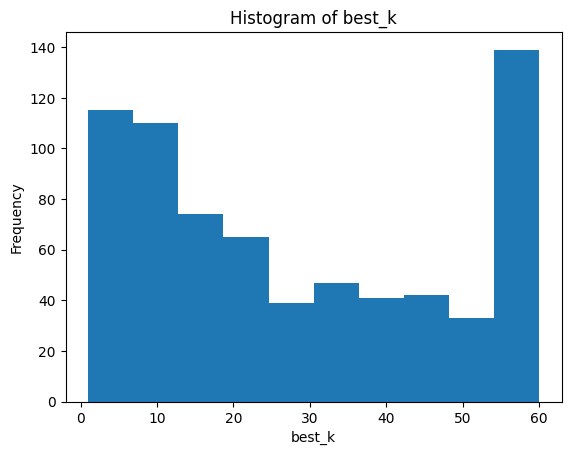

In [90]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(y_df_model["best_k"])
plt.xlabel("best_k")
plt.ylabel("Frequency")
plt.title("Histogram of best_k")
plt.show()

## Define Model

In [91]:
df_model = X_df_model.merge(
    y_df_model,
    on="anonymized_id",
    how="inner"
)

features = df_model.drop(columns=["anonymized_id", "best_k"])
target   = df_model["best_k"]

ids = df_model["anonymized_id"].values
unique_ids = np.unique(ids)

np.random.shuffle(unique_ids)

split = int(0.8 * len(unique_ids))
train_ids = set(unique_ids[:split])
test_ids  = set(unique_ids[split:])

train_mask = df_model["anonymized_id"].isin(train_ids)
test_mask  = df_model["anonymized_id"].isin(test_ids)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_np = scaler.fit_transform(features[train_mask])
X_test_np  = scaler.transform(features[test_mask])

import torch

X_train = torch.tensor(X_train_np, dtype=torch.float32)
X_test  = torch.tensor(X_test_np, dtype=torch.float32)

y_train = torch.tensor(target[train_mask].values, dtype=torch.float32)
y_test  = torch.tensor(target[test_mask].values, dtype=torch.float32)

In [92]:
from torch.utils.data import TensorDataset, DataLoader

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=64)

In [93]:
import torch.nn as nn

class Regressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)  # single continuous output
        )

    def forward(self, x):
        return self.net(x).squeeze(1)
    
model = Regressor(input_dim=X_train.shape[1])

In [94]:
criterion = nn.MSELoss()

In [95]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [96]:
def postprocess_k(preds):
    preds = preds.round()           # nearest integer
    preds = torch.clamp(preds, 1, 60)
    return preds.long()

In [97]:
def evaluate(loader):
    model.eval()
    total_loss = 0

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for xb, yb in loader:
            preds = model(xb)
            loss = criterion(preds, yb)

            total_loss += loss.item() * xb.size(0)

            all_preds.append(preds)
            all_targets.append(yb)

    preds = torch.cat(all_preds)
    targets = torch.cat(all_targets)

    total_loss /= len(loader.dataset)

    return total_loss, preds, targets

In [98]:
best_loss = float("inf")
patience = 20
counter = 0

val_loss, preds, targets = evaluate(test_loader)
print(f"Before training: val_loss={val_loss:.4f}")

for epoch in range(2000):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        logits = model(xb)
        loss = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)

    train_loss = total_loss / len(train_loader.dataset)

    val_loss, _, _ = evaluate(test_loader)

    print(f"Epoch {epoch}: train={train_loss:.4f}, val={val_loss:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
        best_state = model.state_dict()
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping after {epoch} epochs with {patience} patience.")
            break

# restore best model
model.load_state_dict(best_state)

Before training: val_loss=1366.1214
Epoch 0: train=1184.9263, val=1364.6689
Epoch 1: train=1183.6203, val=1363.2784
Epoch 2: train=1182.3641, val=1361.9381
Epoch 3: train=1181.1506, val=1360.6375
Epoch 4: train=1179.9811, val=1359.3701
Epoch 5: train=1178.8430, val=1358.1355
Epoch 6: train=1177.7249, val=1356.9280
Epoch 7: train=1176.6210, val=1355.7336
Epoch 8: train=1175.5431, val=1354.5325
Epoch 9: train=1174.4286, val=1353.3380
Epoch 10: train=1173.3231, val=1352.1301
Epoch 11: train=1172.2142, val=1350.8953
Epoch 12: train=1171.0902, val=1349.6285
Epoch 13: train=1169.9217, val=1348.3404
Epoch 14: train=1168.7435, val=1347.0130
Epoch 15: train=1167.5033, val=1345.6606
Epoch 16: train=1166.2652, val=1344.2402
Epoch 17: train=1164.9350, val=1342.7912
Epoch 18: train=1163.5719, val=1341.2856
Epoch 19: train=1162.1729, val=1339.7054
Epoch 20: train=1160.6955, val=1338.0606
Epoch 21: train=1159.1412, val=1336.3573
Epoch 22: train=1157.5866, val=1334.5335
Epoch 23: train=1155.8774, val=

<All keys matched successfully>

In [99]:
train_loss, train_preds, train_targets = evaluate(train_loader)
test_loss,  test_preds,  test_targets  = evaluate(test_loader)

In [100]:
train_preds_k = postprocess_k(train_preds)
test_preds_k  = postprocess_k(test_preds)

train_targets_k = y_train.long()
test_targets_k  = y_test.long()

In [101]:
df_train = pd.DataFrame({
    "anonymized_id": df_model.loc[train_mask, "anonymized_id"].values,
    "pred_k": train_preds_k.numpy(),
    "true_k": train_targets_k.numpy(),
    "split": "train"
})

df_test = pd.DataFrame({
    "anonymized_id": df_model.loc[test_mask, "anonymized_id"].values,
    "pred_k": test_preds_k.numpy(),
    "true_k": test_targets_k.numpy(),
    "split": "test"
})

df_eval = pd.concat([df_train, df_test], ignore_index=True)

In [102]:
bps_list = []

for _, row in df_eval.iterrows():
    anon_id = row["anonymized_id"]
    k = int(row["pred_k"])

    data = orderbook_data.get(anon_id)

    if data is None:
        bps_list.append(np.nan)
        continue

    bps = compute_bps_for_k(
        k,
        data["ask_prices"],
        data["ask_vols"],
        data["bid_prices"],
        data["bid_vols"],
        data["close_price"]
    )

    bps_list.append(bps)

df_eval["bps"] = bps_list

In [103]:
K_MIN, K_MAX = 1, 60

results = []

for i, (book_id, book) in enumerate(orderbook_data.items()):
    
    # --- extract book fields (adapt to your structure) ---
    ask_prices = book['ask_prices']
    ask_vols   = book['ask_vols']
    bid_prices = book['bid_prices']
    bid_vols   = book['bid_vols']
    close_price = book['close_price']

    # --- sample random K ---
    k = np.random.randint(K_MIN, K_MAX + 1)

    # --- compute bps ---
    bps = compute_bps_for_k(
        k,
        ask_prices,
        ask_vols,
        bid_prices,
        bid_vols,
        close_price
    )

    results.append({
        'id': book_id,
        'k': k,
        'bps': bps
    })

bps_df_random = pd.DataFrame(results)

In [104]:
bps_df = pd.DataFrame({
    "asset": [data_asset],
    "optimal_k_bps": [df_k.loc[df_k["Asset"] == data_asset, "bps_optimal_K"].iloc[0]],
    "model_test_bps": [df_eval.loc[df_eval["split"] == "test", "bps"].mean()]
})

bps_df = pd.concat([bps_df, bps_df_random.agg({'bps': 'mean'}).rename({'bps': 'random_k_bps'}).to_frame().T], axis=1)

bps_df.to_csv(f"bps_comparison_{data_asset}.csv", index=False)

In [105]:
ada = pd.read_csv("bps_comparison_ADAUSDT.csv")
btc = pd.read_csv("bps_comparison_BTCUSDT.csv")
eth = pd.read_csv("bps_comparison_ETHUSDT.csv")
ltc = pd.read_csv("bps_comparison_LTCUSDT.csv")
sol = pd.read_csv("bps_comparison_SOLUSDT.csv")
doge = pd.read_csv("bps_comparison_DOGEUSDT.csv")
xrp = pd.read_csv("bps_comparison_XRPUSDT.csv")

all = pd.concat([ada, btc, eth, ltc, sol, doge, xrp], ignore_index=True)
all.to_csv("bps_comparison_all_assets.csv", index=False)

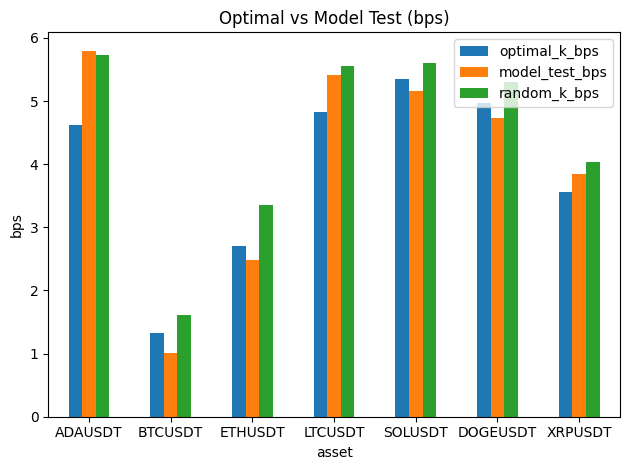

In [107]:
all.set_index('asset')[['optimal_k_bps', 'model_test_bps', 'random_k_bps']].plot(kind='bar')

plt.ylabel('bps')
plt.title('Optimal vs Model Test (bps)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()